In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ast
from scipy import stats
import requests
import re

import warnings

warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

print("Loading final datasets...")
df_topics = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/df_final_topic_sentiment.parquet')
df_entities = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/df_final_entity_sentiment.parquet')


Loading final datasets...


Cleaning dates and creating temporal buckets...
Processing Topics Data:
  -> Found date column: 'date'
Processing Entities Data:
  -> Found date column: 'Date'
Saved Phase5_Macro_Trajectory.png


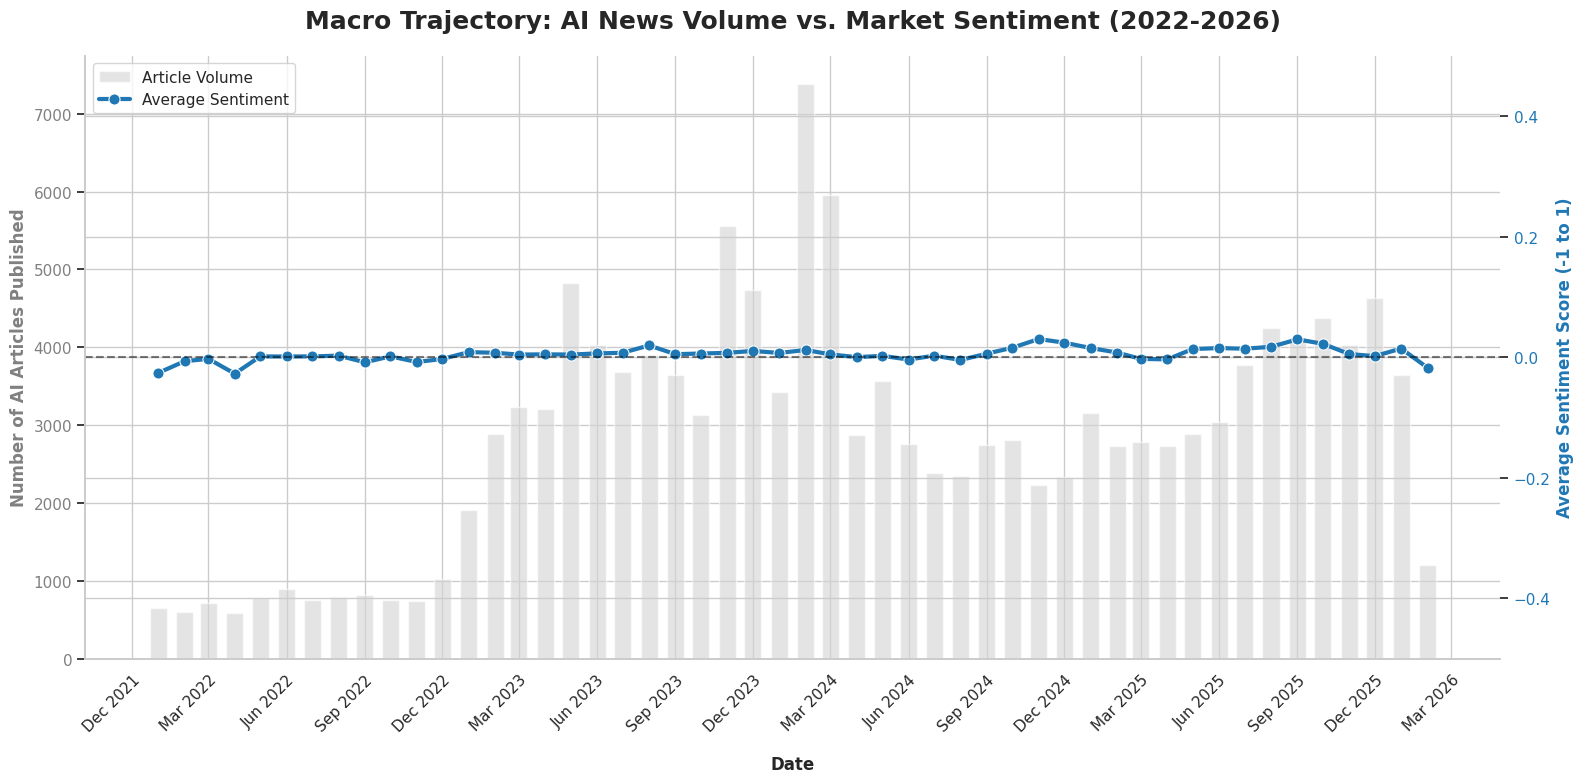

In [ ]:

# Set professional business theme for all charts
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
COLORS = sns.color_palette("tab10")

# ==========================================
# 1. ROBUST TEMPORAL DATA PREPARATION
# ==========================================
def find_date_column(df):
    """Automatically finds the exact name of the date column in a dataframe."""
    for col in ['date', 'Date', 'pub_date', 'Date_Published']:
        if col in df.columns:
            return col
    raise KeyError(f"Could not find a date column! Available columns: {list(df.columns)}")

def clean_dates(df):
    """Converts strings to datetime and drops invalid/outlier years dynamically."""
    df = df.copy()

    # Dynamically grab the correct date column name
    date_col = find_date_column(df)
    print(f"  -> Found date column: '{date_col}'")

    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Drop rows with no valid date
    df = df.dropna(subset=[date_col])

    # Filter for relevant AI boom years 
    df = df[(df[date_col].dt.year >= 2022) & (df[date_col].dt.year <= 2026)]

    # Create a Year-Month bucket for smooth plotting
    df['YearMonth'] = df[date_col].dt.to_period('M').dt.to_timestamp()

    # Standardize the output name
    df['Standard_Date'] = df['YearMonth']
    return df

print("Cleaning dates and creating temporal buckets...")
print("Processing Topics Data:")
df_topics_time = clean_dates(df_topics)

print("Processing Entities Data:")
df_entities_time = clean_dates(df_entities)

# ==========================================
# 2. THE MACRO TREND: Volume vs. Sentiment
# ==========================================
# Group by Month
macro_trend = df_topics_time.groupby('Standard_Date').agg(
    article_count=('cleaned_text_v2', 'count'),
    avg_sentiment=('article_sentiment_score', 'mean')
).reset_index()

# Plotting
fig, ax1 = plt.subplots(figsize=(16, 8))

# Bar chart for Volume 
ax1.bar(macro_trend['Standard_Date'], macro_trend['article_count'], width=20, color='lightgray', alpha=0.6, label='Article Volume')
ax1.set_xlabel('Date', fontsize=12, fontweight='bold', labelpad=15)
ax1.set_ylabel('Number of AI Articles Published', fontsize=12, fontweight='bold', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# Line chart for Sentiment
ax2 = ax1.twinx()
sns.lineplot(data=macro_trend, x='Standard_Date', y='avg_sentiment', ax=ax2, color=COLORS[0], linewidth=3, marker='o', markersize=8, label='Average Sentiment')
ax2.set_ylabel('Average Sentiment Score (-1 to 1)', fontsize=12, fontweight='bold', color=COLORS[0])
ax2.tick_params(axis='y', labelcolor=COLORS[0])
ax2.set_ylim(-0.5, 0.5)

# Add a neutral baseline
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

# Formatting
plt.title('Macro Trajectory: AI News Volume vs. Market Sentiment (2022-2026)', fontsize=18, fontweight='bold', pad=20)

# Set ticks to every 3 months (Quarterly) to reduce crowding
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_Macro_Trajectory.png', dpi=300)
print("Saved Phase5_Macro_Trajectory.png")
plt.show()

### Micro-Trend Analysis: Infrastructure Providers vs. Foundation Model Developers
**Analytical Objective:**
To evaluate the concentration of Generative AI capital expenditure and market dominance, this visualization tracks the sentiment trajectories of key entities driving the foundational layers of the AI technology stack.

**Hypothesis (Based on Goldman Sachs Economic Anchor)**:
While Generative AI presents broad macroeconomic upside, the immediate financial benefits and infrastructural control are heavily concentrated among hyperscalers (cloud providers) and early-mover foundation model developers.

**Methodology & Key Indicators:**
We isolated the entity-level sentiment scores generated by our custom financial BERT model (df_final_entity_sentiment.parquet) for a targeted subset of tech giants. By aggregating these scores on a monthly basis, we can observe:

The Cloud Infrastructure Layer: **bold text**
Tracking AWS (Amazon), GCP (Google), and Azure (Microsoft) to gauge market confidence in enterprise AI scaling capabilities.

The Foundation Model Layer: Tracking OpenAI as the primary catalyst and baseline for Generative AI innovation.

Strategic Divergence: Tracking Meta (representing open-source proliferation) and Apple (representing delayed, hardware-centric integration) to evaluate how differing strategic approaches impact market sentiment over time.

Filtering for Big Tech & Hyperscalers...
Saved Phase5_BigTech_Race.png


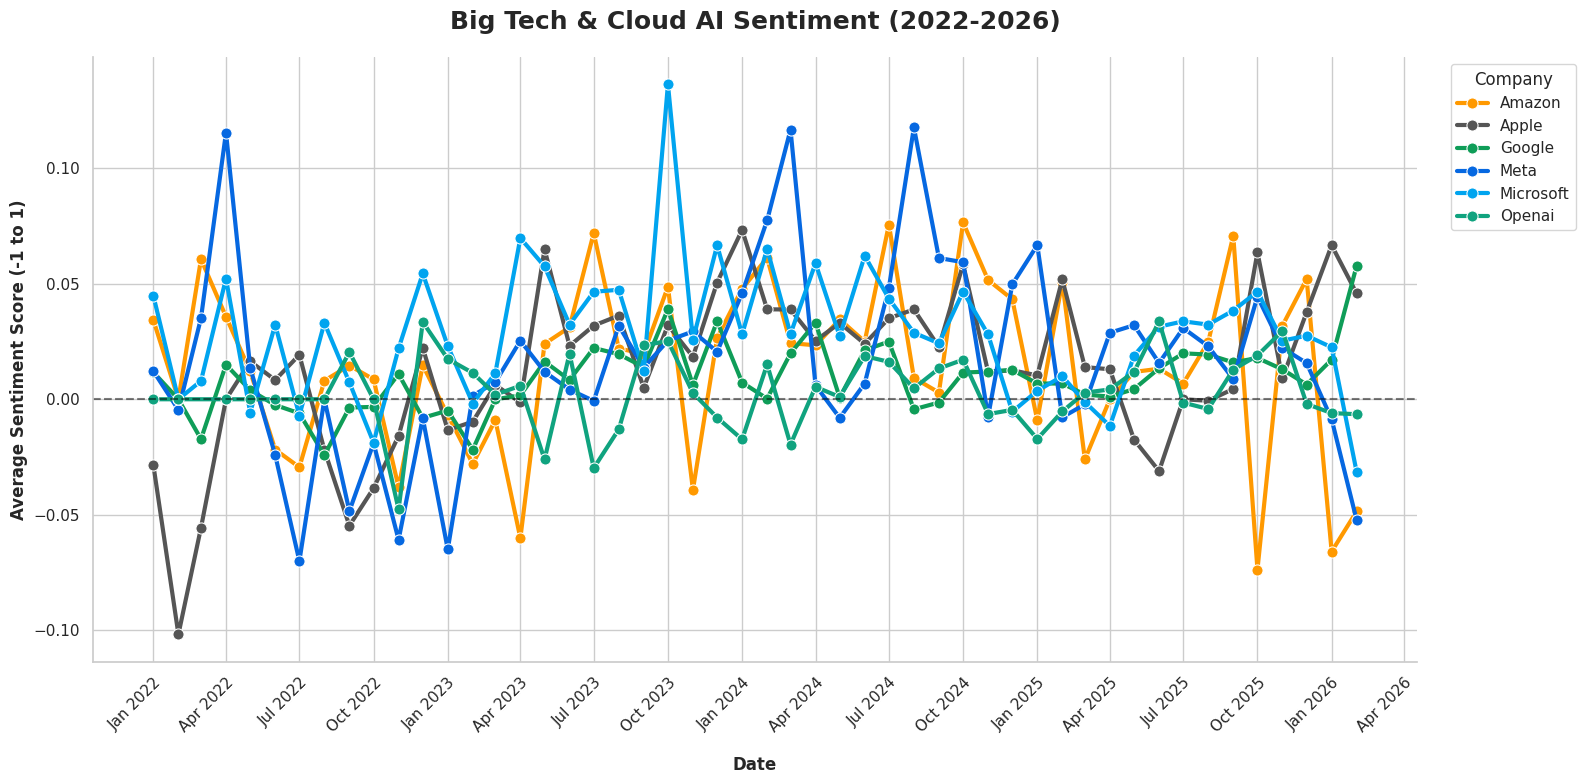

In [ ]:
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# ==========================================
# 3. THE MICRO TREND: Big Tech & Cloud Race
# ==========================================
# Define the major AI/Cloud players to track
target_companies = ['microsoft', 'google', 'openai', 'meta', 'amazon', 'apple']

def map_company(entity_str):
    """Maps messy entity strings to clean corporate labels."""
    if not isinstance(entity_str, str): return None
    entity_lower = entity_str.lower()
    for comp in target_companies:
        if comp in entity_lower:
            return comp.capitalize()
    return None

print("Filtering for Big Tech & Hyperscalers...")
df_entities_time['Target_Company'] = df_entities_time['Entity'].apply(map_company)
df_tech = df_entities_time.dropna(subset=['Target_Company'])

# Aggregate sentiment by Month and Company
tech_trend = df_tech.groupby(['Standard_Date', 'Target_Company']).agg(
    avg_sentiment=('sentiment_score', 'mean'),
    mention_count=('sentiment_score', 'count')
).reset_index()

# Drop months where a company had fewer than 5 mentions to prevent noisy, erratic spikes
tech_trend = tech_trend[tech_trend['mention_count'] >= 5]

# PLOTTING
plt.figure(figsize=(16, 8))

# Custom palette matching corporate brand colors
brand_colors = {
    'Microsoft': '#00a4ef',
    'Google': '#0f9d58',
    'Openai': '#10a37f',
    'Meta': '#0668E1',
    'Amazon': '#ff9900',
    'Apple': '#555555'
}

sns.lineplot(
    data=tech_trend,
    x='Standard_Date',
    y='avg_sentiment',
    hue='Target_Company',
    linewidth=3,
    marker='o',
    markersize=8,
    palette=brand_colors
)

plt.title('Big Tech & Cloud AI Sentiment (2022-2026)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Average Sentiment Score (-1 to 1)', fontsize=12, fontweight='bold')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

# Formatting X-axis 
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Clean Legend
plt.legend(title='Company', fontsize=11, title_fontsize=12, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Save and Show
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_BigTech_Race.png', dpi=300)
print("Saved Phase5_BigTech_Race.png")
plt.show()

Evaluating Targeted Enterprise AI Indices...


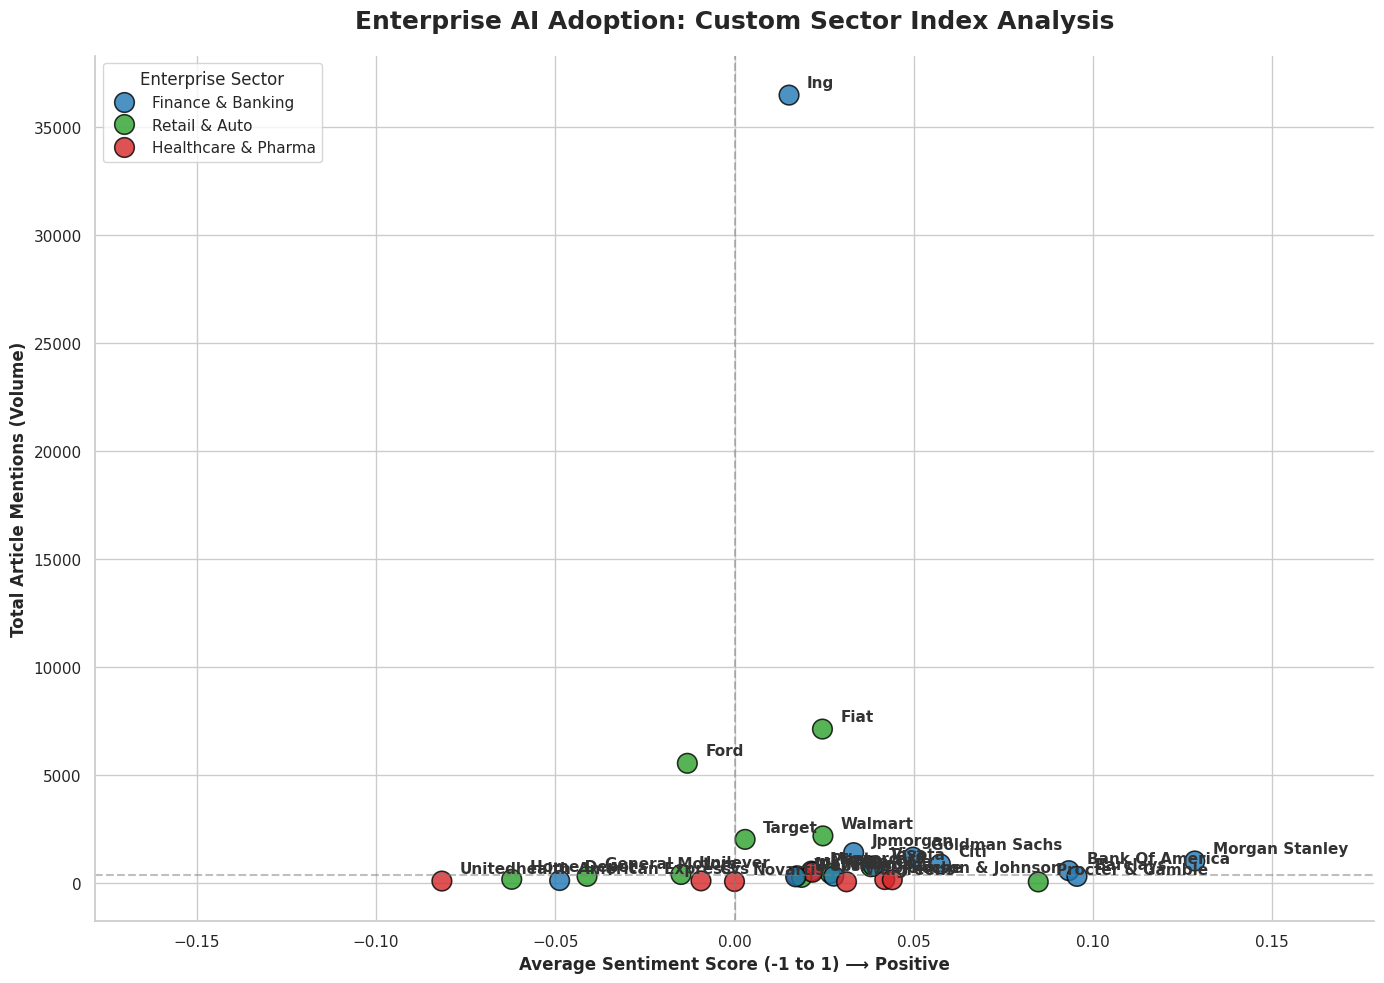


=== ENTERPRISE ADOPTION INDEX RESULTS ===


,Index_Match,Sector,mention_count,avg_sentiment
17,morgan stanley,Finance & Banking,1028,0.128405
2,barclays,Finance & Banking,314,0.095541
1,bank of america,Finance & Banking,579,0.093264
21,procter & gamble,Retail & Auto,59,0.084746
3,citi,Finance & Banking,888,0.057432
9,goldman sachs,Finance & Banking,1205,0.049793
22,roche,Healthcare & Pharma,159,0.044025
13,johnson & johnson,Healthcare & Pharma,167,0.041916
27,visa,Finance & Banking,801,0.038702
24,toyota,Retail & Auto,762,0.038058


In [ ]:
# Set professional business theme
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

print("Evaluating Targeted Enterprise AI Indices...")

# THE INCLUSION INDEX (Targeted Whitelist)
# define exactly what traditional enterprises we want to test.
finance_index = [
    'jpmorgan', 'goldman sachs', 'morgan stanley', 'citi', 'bank of america',
    'wells fargo', 'barclays', 'hsbc', 'visa', 'mastercard', 'american express', 'ing'
]

healthcare_index = [
    'mayo clinic', 'cleveland clinic', 'epic systems', 'johnson & johnson',
    'pfizer', 'unitedhealth', 'cvs', 'walgreens', 'novartis', 'roche'
]

enterprise_retail_index = [
    'walmart', 'target', 'home depot', 'toyota', 'ford', 'general motors',
    'fiat', 'procter & gamble', 'unilever', 'coca-cola', 'pepsi'
]

# Combine the baskets and map them for coloring later
custom_index = {}
for comp in finance_index: custom_index[comp] = 'Finance & Banking'
for comp in healthcare_index: custom_index[comp] = 'Healthcare & Pharma'
for comp in enterprise_retail_index: custom_index[comp] = 'Retail & Auto'

def map_to_index(entity_str):
    """Checks if the entity exactly matches our custom index baskets."""
    if not isinstance(entity_str, str): return None
    ent_lower = entity_str.lower().strip()

    for target_company in custom_index.keys():
        if target_company in ent_lower:
            return target_company
    return None

# Apply the strict inclusion filter
df_entities['Index_Match'] = df_entities['Entity'].apply(map_to_index)
index_df = df_entities.dropna(subset=['Index_Match']).copy()

# Map the sector category
index_df['Sector'] = index_df['Index_Match'].map(custom_index)

# Aggregate Data
adopter_stats = index_df.groupby(['Index_Match', 'Sector']).agg(
    mention_count=('sentiment_score', 'count'),
    avg_sentiment=('sentiment_score', 'mean')
).reset_index()

# Filter out absolute noise (e.g., less than 5 mentions)
adopter_stats = adopter_stats[adopter_stats['mention_count'] >= 5]

# ==========================================
# PLOTTING
# ==========================================
plt.figure(figsize=(14, 10))

# Define colors for our specific sectors
sector_colors = {
    'Finance & Banking': '#1f77b4',     # Blue
    'Healthcare & Pharma': '#d62728',   # Red
    'Retail & Auto': '#2ca02c'          # Green
}

# Create the scatter plot, colored by Sector
sns.scatterplot(
    data=adopter_stats,
    x='avg_sentiment',
    y='mention_count',
    hue='Sector',
    palette=sector_colors,
    alpha=0.8,
    s=200, 
    edgecolor='black'
)

# Draw Quadrant Lines
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(adopter_stats['mention_count'].median(), color='gray', linestyle='--', alpha=0.5)

# Add Labels to ALL matched companies
for _, row in adopter_stats.iterrows():
    plt.text(
        row['avg_sentiment'] + 0.005,
        row['mention_count'] + (adopter_stats['mention_count'].max() * 0.01),
        str(row['Index_Match']).title(),
        fontsize=11,
        fontweight='semibold',
        color='#333333'
    )

# Formatting
plt.title('Enterprise AI Adoption: Custom Sector Index Analysis', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Average Sentiment Score (-1 to 1) ⟶ Positive', fontsize=12, fontweight='bold')
plt.ylabel('Total Article Mentions (Volume)', fontsize=12, fontweight='bold')

# Ensure X-axis is balanced
max_abs_sent = max(abs(adopter_stats['avg_sentiment'].min()), abs(adopter_stats['avg_sentiment'].max()))
plt.xlim(-max_abs_sent - 0.05, max_abs_sent + 0.05)

plt.legend(title='Enterprise Sector', title_fontsize='12', loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_Sector_Index.png', dpi=300)
plt.show()

print("\n=== ENTERPRISE ADOPTION INDEX RESULTS ===")
display(adopter_stats.sort_values('avg_sentiment', ascending=False))

### Using top 500 companies from S & P for analysis

Fetching objective baseline: Live S&P 500 Index...
Cross-referencing extracted NLP entities against the S&P 500...


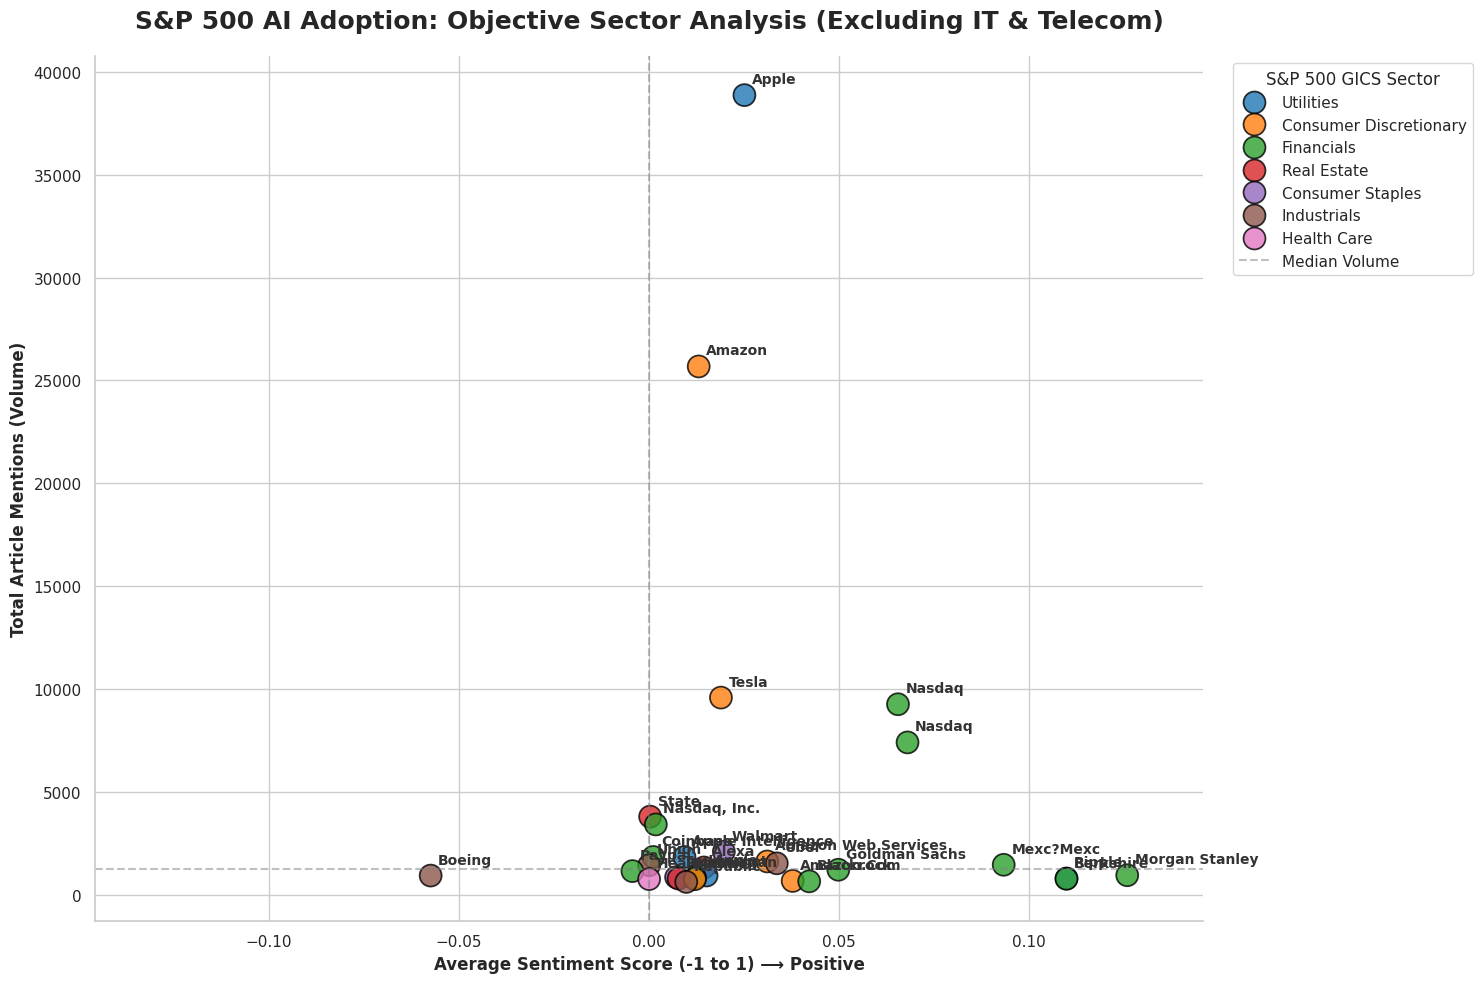


=== THE TRUE DATA-DRIVEN ADOPTERS (TOP 20) ===


,Entity,SP500_Sector,mention_count,avg_sentiment
36,Apple,Utilities,38877,0.025079
20,Amazon,Consumer Discretionary,25682,0.013044
210,Tesla,Consumer Discretionary,9577,0.018899
167,Nasdaq,Financials,9254,0.065485
165,NASDAQ,Financials,7398,0.067991
201,State,Real Estate,3789,0.000264
168,"Nasdaq, Inc.",Financials,3409,0.001760
234,Walmart,Consumer Staples,2085,0.019664
81,Coinbase,Financials,1827,0.001095
40,Apple Intelligence,Utilities,1826,0.009310


In [ ]:

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

print("Fetching objective baseline: Live S&P 500 Index...")

# DYNAMICALLY LOAD S&P 500 CONSTITUENTS 
sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

response = requests.get(sp500_url, headers=headers)
# Parse the HTML text returned by the request
sp500_df = pd.read_html(response.text)[0]

def clean_company_name(name):
    """Normalizes company names to match NLP NER outputs."""
    name = str(name).lower()
    # Remove corporate suffixes
    name = re.sub(r'\b(inc\.|corp\.|co\.|ltd\.|plc|company|corporation|group)\b', '', name)
    # Remove punctuation
    name = re.sub(r'[^a-z0-9\s]', '', name)
    return name.strip()

sp500_df['Clean_Name'] = sp500_df['Security'].apply(clean_company_name)
sp500_mapping = dict(zip(sp500_df['Clean_Name'], sp500_df['GICS Sector']))

# EXCLUDE tech sectors to find the non-tech Silent Adopters
excluded_sectors = ['Information Technology', 'Communication Services']

def map_to_sp500_sector(entity_str):
    """Cross-references an extracted entity with the S&P 500."""
    if not isinstance(entity_str, str) or len(entity_str) <= 3:
        return None

    ent_lower = clean_company_name(entity_str)

    # 1. Exact Match
    if ent_lower in sp500_mapping:
        sector = sp500_mapping[ent_lower]
        if sector not in excluded_sectors: return sector

    # 2. Substring Match for major corporate names
    for sp_name, sector in sp500_mapping.items():
        if len(ent_lower) >= 5 and (ent_lower in sp_name or sp_name in ent_lower):
            if sector not in excluded_sectors: return sector

    return None

print("Cross-referencing extracted NLP entities against the S&P 500...")
# Apply mapping to find the true, objective enterprise adopters
df_entities['SP500_Sector'] = df_entities['Entity'].apply(map_to_sp500_sector)
index_df = df_entities.dropna(subset=['SP500_Sector']).copy()

#  AGGREGATE DATA
adopter_stats = index_df.groupby(['Entity', 'SP500_Sector']).agg(
    mention_count=('sentiment_score', 'count'),
    avg_sentiment=('sentiment_score', 'mean')
).reset_index()

# Filter out companies with fewer than 10 mentions to ensure statistical relevance
adopter_stats = adopter_stats[adopter_stats['mention_count'] >= 10]

# Sort to find the objectively top mentioned companies
top_adopters = adopter_stats.sort_values(
    by=['mention_count', 'avg_sentiment'],
    ascending=[False, False]
).head(30)

# PLOTTING
plt.figure(figsize=(15, 10))

# Create scatter plot colored objectively by S&P 500 GICS Sector
sns.scatterplot(
    data=top_adopters,
    x='avg_sentiment',
    y='mention_count',
    hue='SP500_Sector',
    palette='tab10',
    alpha=0.8,
    s=250,
    edgecolor='black'
)

# Draw Quadrant Lines
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(top_adopters['mention_count'].median(), color='gray', linestyle='--', alpha=0.5, label='Median Volume')

# Add Labels
for _, row in top_adopters.iterrows():
    plt.text(
        row['avg_sentiment'] + 0.002,
        row['mention_count'] + (top_adopters['mention_count'].max() * 0.015),
        str(row['Entity']).title(),
        fontsize=10,
        fontweight='semibold',
        color='#333333'
    )

# Formatting
plt.title('S&P 500 AI Adoption: Objective Sector Analysis (Excluding IT & Telecom)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Average Sentiment Score (-1 to 1) ⟶ Positive', fontsize=12, fontweight='bold')
plt.ylabel('Total Article Mentions (Volume)', fontsize=12, fontweight='bold')

# Balance X-axis
max_abs_sent = max(abs(top_adopters['avg_sentiment'].min()), abs(top_adopters['avg_sentiment'].max()))
plt.xlim(-max_abs_sent - 0.02, max_abs_sent + 0.02)

plt.legend(title='S&P 500 GICS Sector', title_fontsize='12', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_SP500_Adopters.png', dpi=300)
plt.show()

print("\n=== THE TRUE DATA-DRIVEN ADOPTERS (TOP 20) ===")
display(top_adopters[['Entity', 'SP500_Sector', 'mention_count', 'avg_sentiment']].head(20))

Executing Statistical Filtering for Legacy Enterprises...


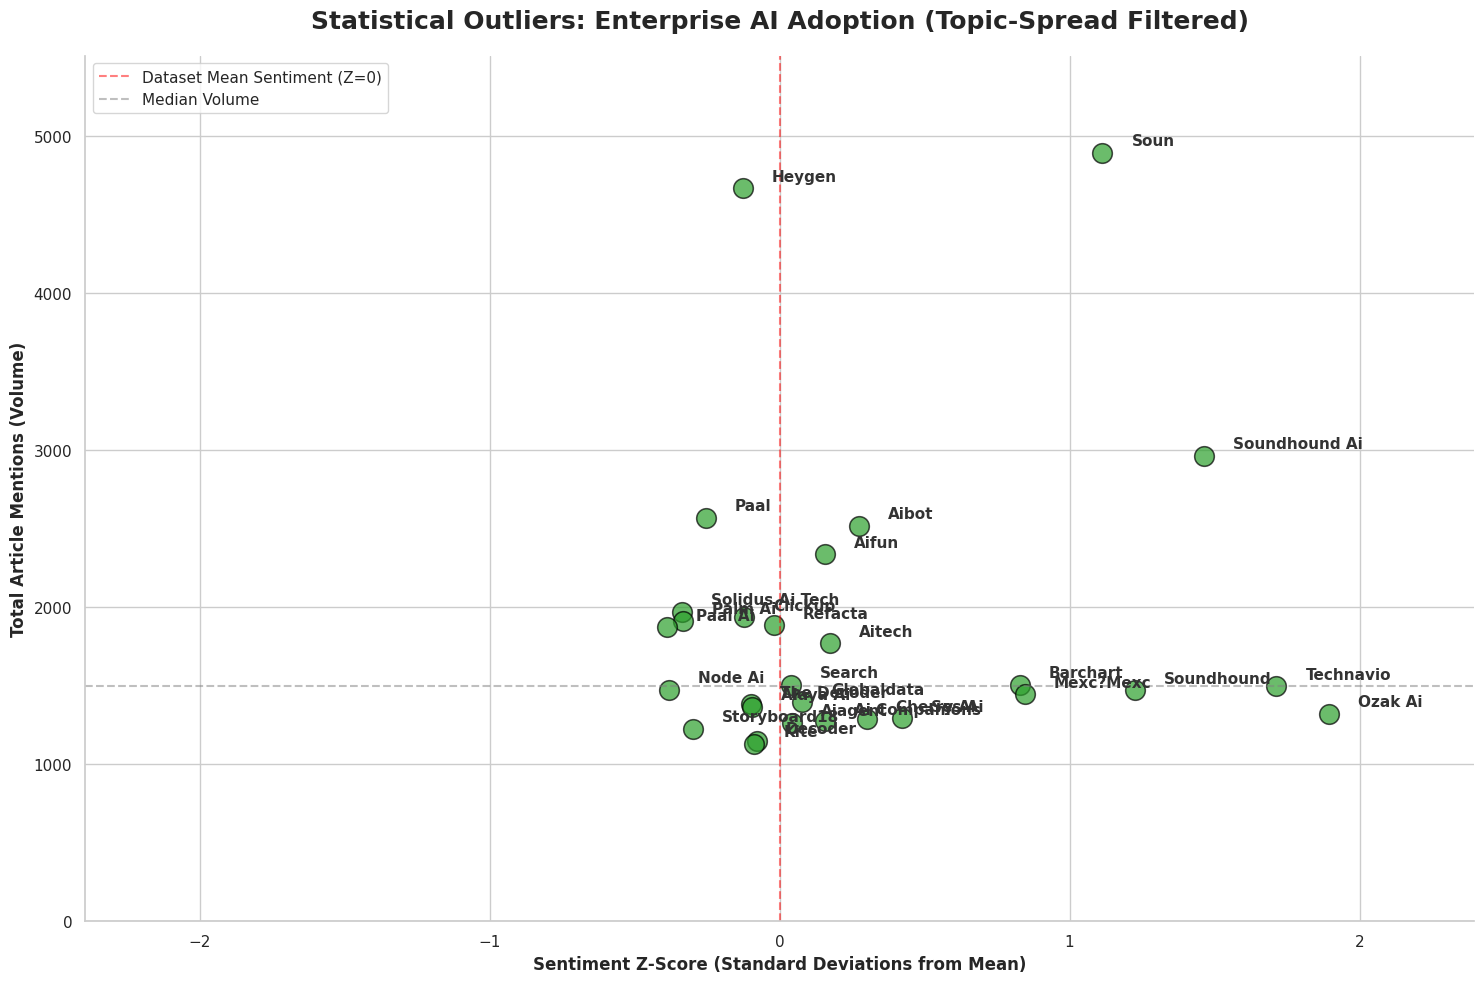


=== THE STATISTICALLY TRUE ADOPTERS (TOP 15) ===


,Entity,mention_count,topic_spread,sentiment_z_score
1638,Fiat,6049,5,-0.017361
4020,SOUN,4896,6,1.113190
2068,HeyGen,4671,5,-0.127743
4225,SoundHound AI,2965,4,1.462974
3503,PAAL,2572,2,-0.255016
112,AIBOT,2521,2,0.272990
116,AIFUN,2337,2,0.155981
4213,Solidus Ai Tech,1973,3,-0.337225
1059,ClickUp,1936,4,-0.121722
3571,PaLM AI,1915,2,-0.332007


In [ ]:
# Set professional business theme
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

print("Executing Statistical Filtering for Legacy Enterprises...")

# AGGREGATE STATS PER ENTITY
# calculate Volume, Raw Sentiment, and our new 'Topic Spread' metric
entity_stats = df_entities.groupby('Entity').agg(
    mention_count=('sentiment_score', 'count'),
    avg_sentiment=('sentiment_score', 'mean'),
    topic_spread=('Topic_ID', 'nunique') # How many different topics does it appear in?
).reset_index()

# APPLY STRICT STATISTICAL FILTERS

# Filter A: Length Constraint (Eliminates NER character hallucinations like 'X', 'CA', 'AI')
entity_stats = entity_stats[entity_stats['Entity'].astype(str).str.len() >= 4]

# Filter B: Volume Constraint (Ensures statistical significance)
entity_stats = entity_stats[entity_stats['mention_count'] >= 20]

# Filter C: The "Topic Spread" Filter (Eliminates Publishers & Broad Indices)
# If a company appears in more than 20% of all distinct topics, it's structurally generic.
total_topics = df_entities['Topic_ID'].nunique()
max_topics_allowed = max(3, int(total_topics * 0.20))
entity_stats = entity_stats[entity_stats['topic_spread'] <= max_topics_allowed]

# Filter D: Remove explicitly tagged Tech Giants (Targeted exclusion)
tech_giants = ['microsoft', 'google', 'openai', 'meta', 'amazon', 'apple', 'nvidia', 'alphabet']
entity_stats = entity_stats[~entity_stats['Entity'].str.lower().isin(tech_giants)]

# 3. CALCULATE Z-SCORES (Standardizing the Sentiment)
# This reveals who is performing exceptionally well relative to the dataset's baseline
mean_sentiment = entity_stats['avg_sentiment'].mean()
std_sentiment = entity_stats['avg_sentiment'].std()

entity_stats['sentiment_z_score'] = (entity_stats['avg_sentiment'] - mean_sentiment) / std_sentiment

# Sort to identify the true statistical outliers (High Volume, High Z-Score)
top_adopters = entity_stats.sort_values(
    by=['mention_count', 'sentiment_z_score'],
    ascending=[False, False]
).head(30)

# Calculate zoom limit for plotting (95th percentile of volume to avoid Y-axis squashing)
y_max_zoom = top_adopters['mention_count'].quantile(0.95)

# PLOTTING

plt.figure(figsize=(15, 10))

# Plot using the Z-Score on the X-Axis 
sns.scatterplot(
    data=top_adopters,
    x='sentiment_z_score',
    y='mention_count',
    alpha=0.7,
    color='#2ca02c',
    s=200,
    edgecolor='black'
)

# Draw Quadrant Lines
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Dataset Mean Sentiment (Z=0)')
plt.axhline(top_adopters['mention_count'].median(), color='gray', linestyle='--', alpha=0.5, label='Median Volume')

# Add Labels
for _, row in top_adopters.iterrows():
    if row['mention_count'] <= y_max_zoom * 1.1:
        plt.text(
            row['sentiment_z_score'] + 0.1,  
            row['mention_count'] + (y_max_zoom * 0.01),
            str(row['Entity']).title(),
            fontsize=11,
            fontweight='semibold',
            color='#333333'
        )

# Formatting
plt.title('Statistical Outliers: Enterprise AI Adoption (Topic-Spread Filtered)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Sentiment Z-Score (Standard Deviations from Mean)', fontsize=12, fontweight='bold')
plt.ylabel('Total Article Mentions (Volume)', fontsize=12, fontweight='bold')

# Balance X-axis based on Z-scores (usually between -3 and +3)
max_z = max(abs(top_adopters['sentiment_z_score'].min()), abs(top_adopters['sentiment_z_score'].max()))
plt.xlim(-max_z - 0.5, max_z + 0.5)
plt.ylim(0, y_max_zoom + (y_max_zoom * 0.15))

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_Statistical_Adopters.png', dpi=300)
plt.show()

print("\n=== THE STATISTICALLY TRUE ADOPTERS (TOP 15) ===")
display(top_adopters[['Entity', 'mention_count', 'topic_spread', 'sentiment_z_score']].head(15))

## TOPIC ANALYSIS

Evaluating Macro-Level Topic Sentiment...


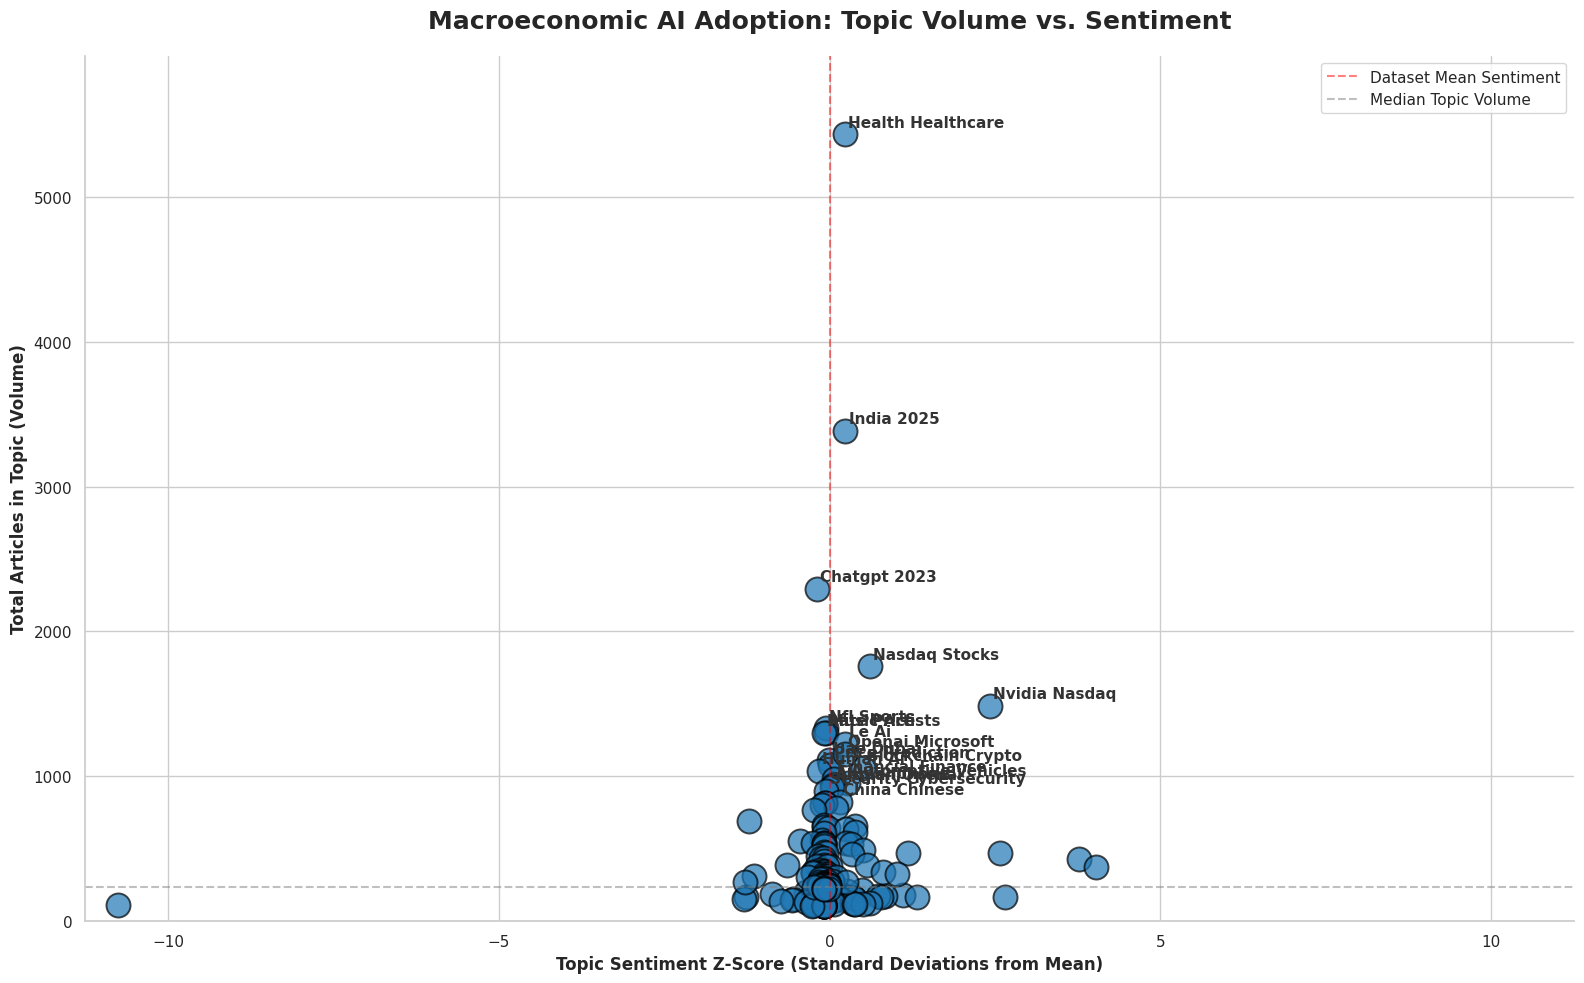


=== TOP MACRO THEMES BY SENTIMENT ===


,Topic_Name,article_count,avg_sentiment,sentiment_z_score
136,4_nvidia_nasdaq_stock_chips,1484,0.138140,2.417319
125,3_nasdaq_stocks_stock_markets,1759,0.038090,0.602213
34,12_blockchain_crypto_trading_ai,1061,0.032988,0.509651
67,15_automotive_vehicles_vehicle_driving,957,0.019854,0.271375
103,1_india_2025_indian_delhi,3383,0.018031,0.238313
180,8_le_ai_ka_fa,1223,0.017989,0.237537
1,0_health_healthcare_patient_medical,5430,0.017495,0.228590
191,9_openai_microsoft_billion_altman,1154,0.017331,0.225608
102,19_china_chinese_beijing_xi,823,0.013366,0.153670
56,14_financial_finance_banking_fraud,982,0.008147,0.058986


In [ ]:

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

print("Evaluating Macro-Level Topic Sentiment...")

# AGGREGATE STATS PER TOPIC
# Group by the BERTopic Names you generated in Phase 3
topic_stats = df_topics_time.groupby('Topic_Name').agg(
    article_count=('cleaned_text_v2', 'count'),
    avg_sentiment=('article_sentiment_score', 'mean')
).reset_index()

# Drop the "-1" outlier topic (BERTopic's default "Unclustered Noise" bin)
topic_stats = topic_stats[~topic_stats['Topic_Name'].astype(str).str.startswith('-1')]

# Filter out tiny micro-topics to focus on major macroeconomic themes
topic_stats = topic_stats[topic_stats['article_count'] >= 50]

# Calculate Z-Scores for Sentiment to stretch the axis naturally (as discussed)
mean_sent = topic_stats['avg_sentiment'].mean()
std_sent = topic_stats['avg_sentiment'].std()
topic_stats['sentiment_z_score'] = (topic_stats['avg_sentiment'] - mean_sent) / std_sent

#  IDENTIFY THE LEADERS
# Sort by volume to label the biggest topics
top_topics = topic_stats.sort_values(by='article_count', ascending=False).head(20)
y_max_zoom = top_topics['article_count'].max()

# PLOTTING

plt.figure(figsize=(16, 10))

# Create the scatter plot
sns.scatterplot(
    data=topic_stats,
    x='sentiment_z_score',
    y='article_count',
    alpha=0.7,
    color='#1f77b4', 
    s=300,
    edgecolor='black'
)

# Draw Quadrant Lines
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Dataset Mean Sentiment')
plt.axhline(topic_stats['article_count'].median(), color='gray', linestyle='--', alpha=0.5, label='Median Topic Volume')

# Add Labels to the Top 20 Topics
for _, row in top_topics.iterrows():
    # Clean up the BERTopic name (e.g., "0_healthcare_medical_doctor" -> "Healthcare Medical")
    raw_name = str(row['Topic_Name'])
    clean_name = " ".join(raw_name.split('_')[1:3]).title() if '_' in raw_name else raw_name

    plt.text(
        row['sentiment_z_score'] + 0.05,
        row['article_count'] + (y_max_zoom * 0.01),
        clean_name,
        fontsize=11,
        fontweight='semibold',
        color='#333333'
    )

# Formatting
plt.title('Macroeconomic AI Adoption: Topic Volume vs. Sentiment', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Topic Sentiment Z-Score (Standard Deviations from Mean)', fontsize=12, fontweight='bold')
plt.ylabel('Total Articles in Topic (Volume)', fontsize=12, fontweight='bold')

# Balance X-axis
max_z = max(abs(topic_stats['sentiment_z_score'].min()), abs(topic_stats['sentiment_z_score'].max()))
plt.xlim(-max_z - 0.5, max_z + 0.5)
plt.ylim(0, y_max_zoom + (y_max_zoom * 0.1))

plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_Topic_Matrix.png', dpi=300)
plt.show()

print("\n=== TOP MACRO THEMES BY SENTIMENT ===")
display(top_topics[['Topic_Name', 'article_count', 'avg_sentiment', 'sentiment_z_score']].sort_values('sentiment_z_score', ascending=False).head(15))

Generating Temporal Topic Heatmap...


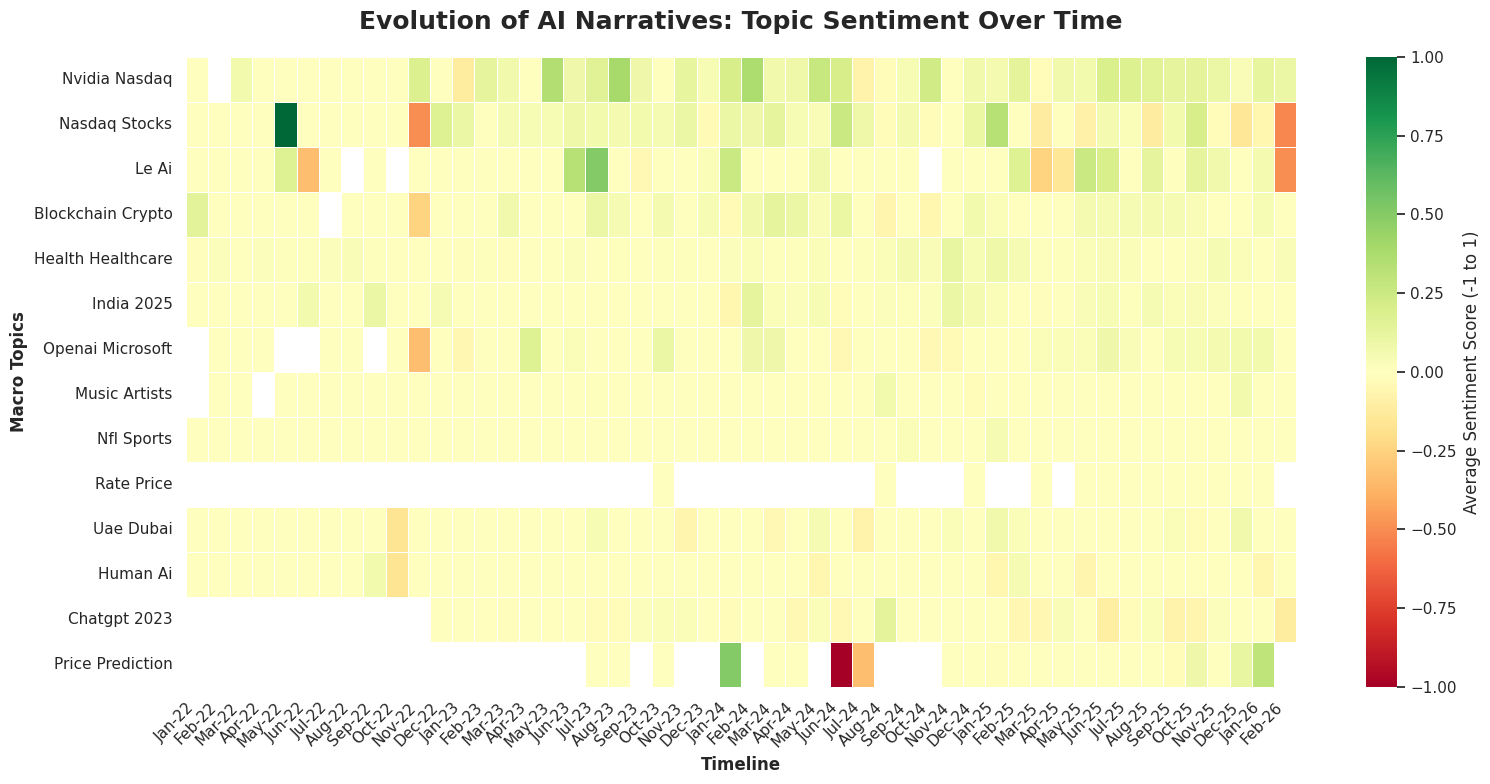

✓ Saved Phase5_Topic_Heatmap.png


In [ ]:

sns.set_theme(style="white")

print("Generating Temporal Topic Heatmap...")

# AGGREGATE SENTIMENT BY TOPIC AND TIME (Standard_Date)
topic_time_stats = df_topics_time.groupby(['Standard_Date', 'Topic_Name']).agg(
    avg_sentiment=('article_sentiment_score', 'mean'),
    mention_count=('article_sentiment_score', 'count')
).reset_index()

#  FILTER FOR TOP MACRO THEMES

# Get the top 15 topics by total volume
top_topic_names = topic_time_stats.groupby('Topic_Name')['mention_count'].sum().nlargest(15).index
heatmap_data = topic_time_stats[topic_time_stats['Topic_Name'].isin(top_topic_names)].copy()

# Clean up Topic Names for the Y-axis (e.g., "0_healthcare_medical_doctor" -> "Healthcare & Medical")
def clean_topic_name(raw_name):
    raw_name = str(raw_name)
    if raw_name.startswith('-1'): return "Uncategorized Noise"
    parts = raw_name.split('_')
    if len(parts) > 2:
        return " ".join(parts[1:3]).title()
    return raw_name

heatmap_data['Clean_Topic'] = heatmap_data['Topic_Name'].apply(clean_topic_name)

# PIVOT THE DATA FOR THE HEATMAP
# Rows = Topics, Columns = Dates, Values = Sentiment
pivot_df = heatmap_data.pivot(index='Clean_Topic', columns='Standard_Date', values='avg_sentiment')

# Drop the noise cluster if it's in there
if "Uncategorized Noise" in pivot_df.index:
    pivot_df = pivot_df.drop("Uncategorized Noise")

# Format column dates nicely for the X-axis
pivot_df.columns = [pd.to_datetime(str(col)).strftime('%b-%y') for col in pivot_df.columns]

# Reorder rows based on overall mean sentiment (Positive at top, Negative at bottom)
pivot_df['mean_sent'] = pivot_df.mean(axis=1)
pivot_df = pivot_df.sort_values('mean_sent', ascending=False).drop(columns=['mean_sent'])


# PLOTTING

plt.figure(figsize=(16, 8))

# Draw the heatmap
# cmap="RdYlGn" gives us Red (Negative), Yellow (Neutral), Green (Positive)
# center=0 ensures that absolute neutral is exactly in the middle of the color scale
ax = sns.heatmap(
    pivot_df,
    cmap="RdYlGn",
    center=0,
    annot=False, # Set to True if you want the exact numbers in the boxes
    linewidths=.5,
    cbar_kws={'label': 'Average Sentiment Score (-1 to 1)'}
)

# Formatting
plt.title('Evolution of AI Narratives: Topic Sentiment Over Time', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Timeline', fontsize=12, fontweight='bold')
plt.ylabel('Macro Topics', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontweight='medium')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_Topic_Heatmap.png', dpi=300)
plt.show()

print("✓ Saved Phase5_Topic_Heatmap.png")

## Analysing the data for the 3 Questions to be answered

In [12]:
df_topics.columns.to_list()

['url',
 'date',
 'language',
 'title',
 'text',
 'cleaned_text',
 'amp_text',
 'amp_dateline_removed',
 'amp_footer_removed',
 'title_found',
 'cleaned_text_v2',
 'lang',
 'text_hash',
 'organizations',
 'technologies',
 'industries',
 'impacts',
 'Topic_ID',
 'Topic_Name',
 'article_sentiment_label',
 'article_sentiment_score']

Mapping Technologies to Industries using Topic & Text Analysis...
Scanning 17,537 industry-specific articles for technological drivers...


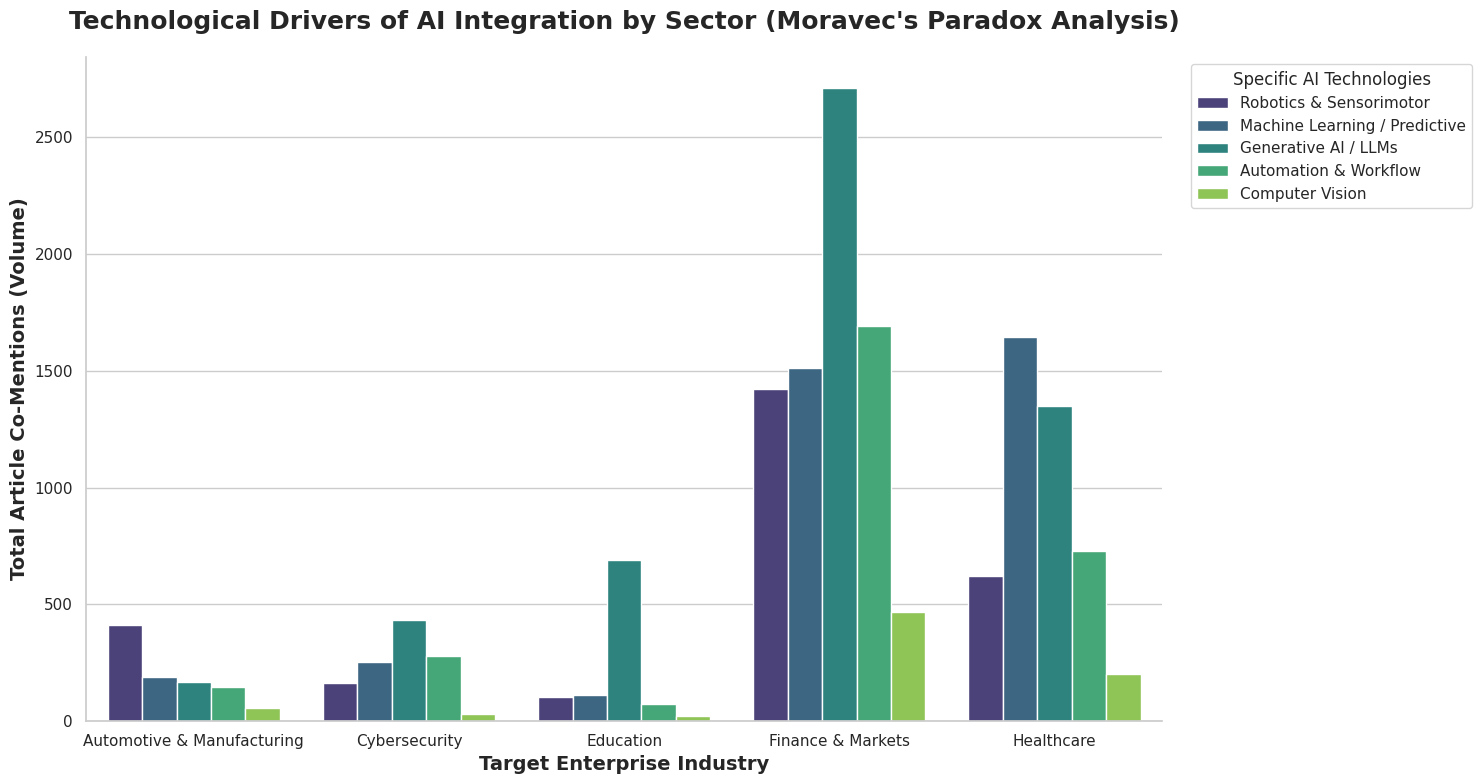


=== TOP TECH DRIVERS & AVERAGE SENTIMENT ===


,Industry,Technology,mention_count,avg_sentiment
4,Automotive & Manufacturing,Robotics & Sensorimotor,414,0.036232
3,Automotive & Manufacturing,Machine Learning / Predictive,189,0.042328
2,Automotive & Manufacturing,Generative AI / LLMs,167,0.035928
0,Automotive & Manufacturing,Automation & Workflow,146,0.061644
1,Automotive & Manufacturing,Computer Vision,58,0.120690
7,Cybersecurity,Generative AI / LLMs,432,0.000000
5,Cybersecurity,Automation & Workflow,281,0.000000
8,Cybersecurity,Machine Learning / Predictive,254,0.000000
9,Cybersecurity,Robotics & Sensorimotor,163,0.000000
6,Cybersecurity,Computer Vision,31,0.000000


In [ ]:

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

print("Mapping Technologies to Industries using Topic & Text Analysis...")

# LOAD THE MAIN DATAFRAME
# df_path = '/content/drive/MyDrive/Colab Notebooks/df_final_topic_sentiment.parquet'
# df = pd.read_parquet(df_path)

#  MAP TOPICS TO INDUSTRIES (Based on your BERTopic results)
def map_topic_to_industry(topic_name):
    topic = str(topic_name).lower()
    if 'healthcare' in topic or 'medical' in topic or 'patient' in topic:
        return 'Healthcare'
    elif 'automotive' in topic or 'vehicle' in topic:
        return 'Automotive & Manufacturing'
    elif 'crypto' in topic or 'nasdaq' in topic or 'market' in topic or 'rate' in topic or 'finance' in topic or 'bank' in topic:
        return 'Finance & Markets'
    elif 'security' in topic or 'cyber' in topic:
        return 'Cybersecurity'
    elif 'education' in topic or 'student' in topic:
        return 'Education'
    return 'Other'

df_topics['Industry_Category'] = df_topics['Topic_Name'].apply(map_topic_to_industry)

# Filter out 'Other' to focus strictly on legacy enterprise sectors
df_target = df_topics[df_topics['Industry_Category'] != 'Other'].copy()

# DEFINE TECHNOLOGY KEYWORDS (Directly aligning with the Capstone Rubric & Prompt)
tech_keywords = {
    'Generative AI / LLMs': ['generative ai', 'genai', 'llm', 'large language model', 'chatgpt', 'gpt-4', 'foundation model'],
    'Machine Learning / Predictive': ['machine learning', 'predictive analytics', 'deep learning', 'neural network'],
    'Automation & Workflow': ['automation', 'rpa', 'robotic process', 'automated workflow', 'cost reduction'],
    'Computer Vision': ['computer vision', 'image recognition', 'facial recognition', 'visual cortex'],
    'Robotics & Sensorimotor': ['robotics', 'robot', 'autonomous', 'sensorimotor', 'physical task']
}

# FAST TEXT-BASED EXTRACTION
tech_records = []
print(f"Scanning {len(df_target):,} industry-specific articles for technological drivers...")

for _, row in df_target.iterrows():
    text = str(row['cleaned_text_v2']).lower()
    industry = row['Industry_Category']
    sentiment = row['article_sentiment_score']

    # Check which technologies are mentioned in this article
    for tech_name, keywords in tech_keywords.items():
        if any(kw in text for kw in keywords):
            tech_records.append({
                'Industry': industry,
                'Technology': tech_name,
                'Sentiment': sentiment
            })

tech_df = pd.DataFrame(tech_records)

#  AGGREGATE THE DATA
tech_stats = tech_df.groupby(['Industry', 'Technology']).agg(
    mention_count=('Sentiment', 'count'),
    avg_sentiment=('Sentiment', 'mean')
).reset_index()

# Sort for the plot
top_techs = tech_stats.sort_values(['Industry', 'mention_count'], ascending=[True, False])

# PLOTTING

plt.figure(figsize=(15, 8))

sns.barplot(
    data=top_techs,
    x='Industry',
    y='mention_count',
    hue='Technology',
    palette='viridis'
)

# Formatting
plt.title('Technological Drivers of AI Integration by Sector (Moravec\'s Paradox Analysis)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Target Enterprise Industry', fontsize=14, fontweight='bold')
plt.ylabel('Total Article Co-Mentions (Volume)', fontsize=14, fontweight='bold')

plt.legend(title='Specific AI Technologies', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_Tech_Drivers.png', dpi=300)
plt.show()

print("\n=== TOP TECH DRIVERS & AVERAGE SENTIMENT ===")
display(top_techs)

Aggregating Industry -> Technology -> Impact Mechanisms...


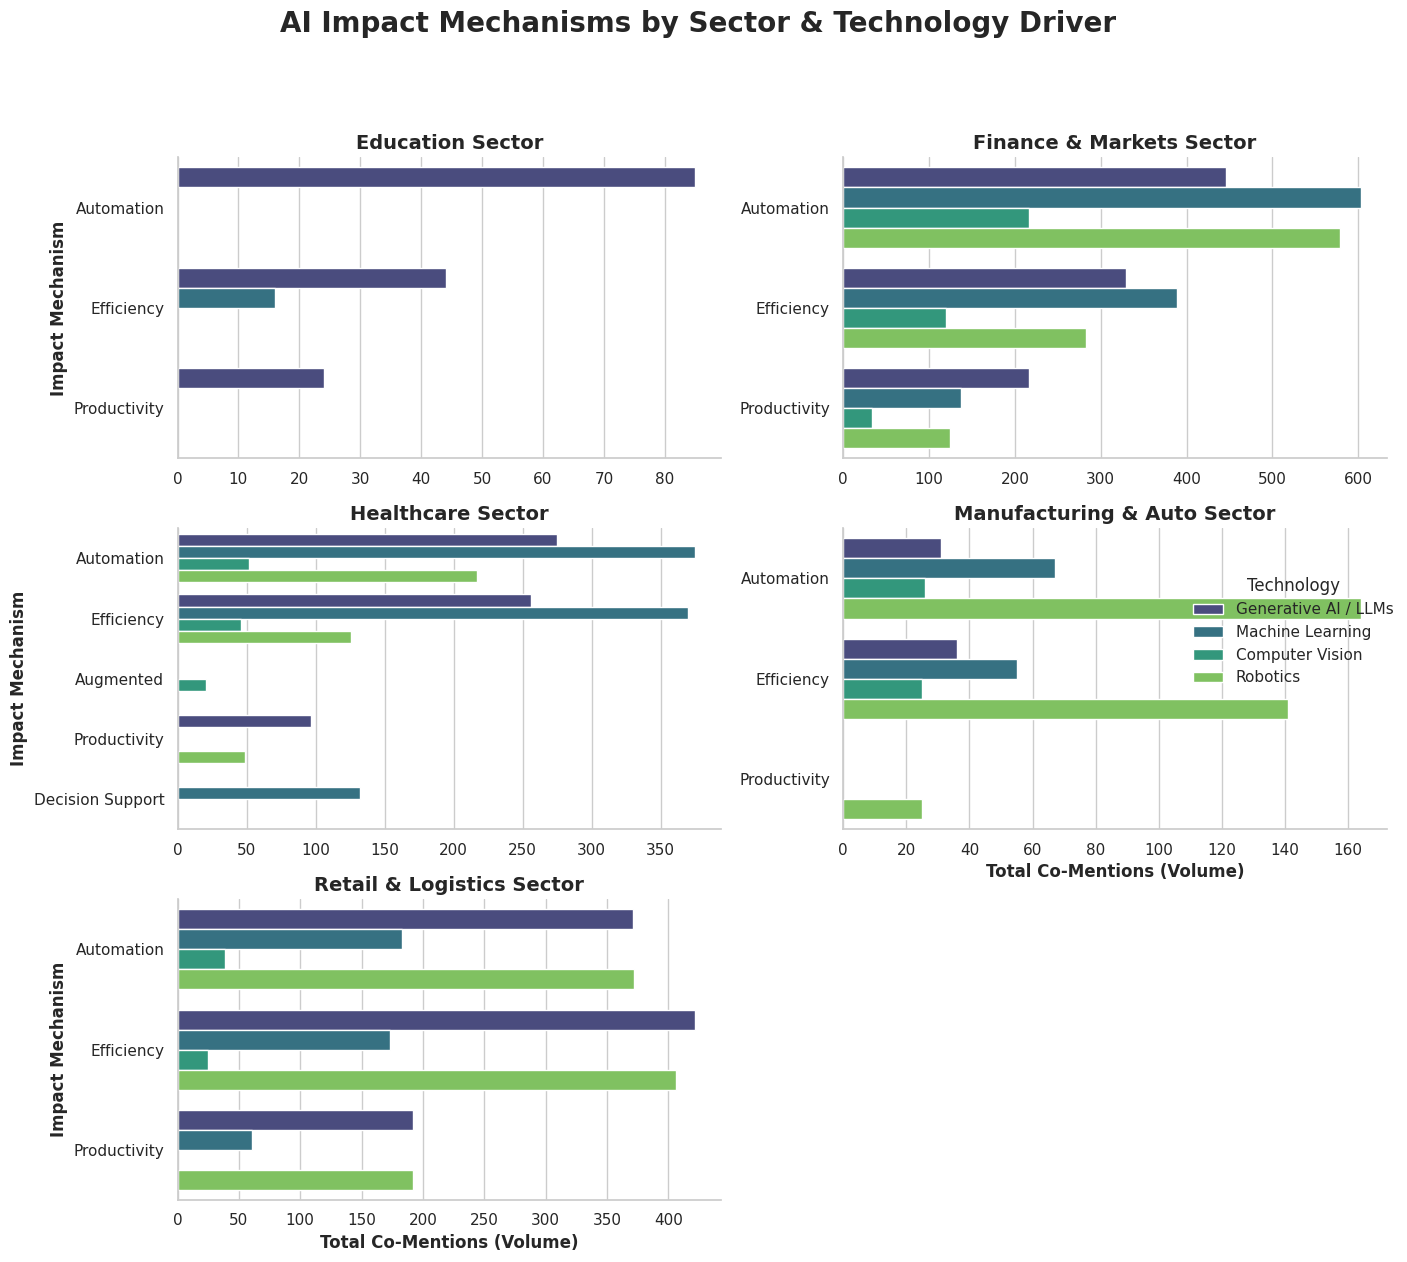


=== TOP COMBINATIONS BY SENTIMENT ===


,Industry,Technology,Impact Mechanism,mention_count,avg_sentiment
25,Healthcare,Computer Vision,Efficiency,46,0.326087
24,Healthcare,Computer Vision,Automation,52,0.211538
37,Manufacturing & Auto,Computer Vision,Efficiency,25,0.200000
12,Finance & Markets,Computer Vision,Automation,217,0.175115
13,Finance & Markets,Computer Vision,Efficiency,120,0.175000
21,Finance & Markets,Robotics,Automation,579,0.138169
22,Finance & Markets,Robotics,Efficiency,283,0.134276
23,Finance & Markets,Robotics,Productivity,124,0.120968
18,Finance & Markets,Machine Learning,Automation,603,0.111111
20,Finance & Markets,Machine Learning,Productivity,137,0.109489


In [ ]:

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

print("Aggregating Industry -> Technology -> Impact Mechanisms...")

# LOAD THE MAIN DATAFRAME
df_path = '/content/drive/MyDrive/Colab Notebooks/df_final_topic_sentiment.parquet'
df = pd.read_parquet(df_path)

# MAP TOPICS TO INDUSTRIES (Using your highly accurate BERTopic clusters)
def map_topic_to_industry(topic_name):
    topic = str(topic_name).lower()
    if 'healthcare' in topic or 'medical' in topic or 'patient' in topic: return 'Healthcare'
    elif 'finance' in topic or 'bank' in topic or 'market' in topic: return 'Finance & Markets'
    elif 'automotive' in topic or 'vehicle' in topic: return 'Manufacturing & Auto'
    elif 'education' in topic or 'student' in topic: return 'Education'
    elif 'retail' in topic or 'supply' in topic: return 'Retail & Logistics'
    return 'Other'

df['Industry'] = df['Topic_Name'].apply(map_topic_to_industry)
df_target = df[df['Industry'] != 'Other'].copy()

# DEFINE KEYWORDS (Aligning perfectly with the Rubric & Phase 2)
tech_keywords = {
    'Generative AI / LLMs': ['generative ai', 'genai', 'llm', 'chatgpt', 'foundation model'],
    'Machine Learning': ['machine learning', 'predictive analytics', 'deep learning'],
    'Computer Vision': ['computer vision', 'image recognition', 'visual cortex'],
    'Robotics': ['robotics', 'robot', 'autonomous', 'sensorimotor']
}

backup_impact_keywords = {
    'Automation': ['automation', 'automated'],
    'Workflow Redesign': ['workflow redesign', 'process optimization'],
    'Cost Reduction': ['cost reduction', 'cost savings'],
    'Decision Support': ['decision support', 'efficiency', 'productivity']
}

# CROSS-DIMENSIONAL EXTRACTION
records = []
has_impacts_col = 'impacts' in df_target.columns

for _, row in df_target.iterrows():
    text = str(row.get('cleaned_text_v2', '')).lower()
    industry = row['Industry']
    sentiment = row.get('article_sentiment_score', 0)

    # Extract Technologies
    found_techs = [tech for tech, kws in tech_keywords.items() if any(kw in text for kw in kws)]
    if not found_techs: continue

    # Extract Impacts 
    found_impacts = []
    if has_impacts_col:
        imps = row.get('impacts', [])
        if isinstance(imps, str):
            try: imps = ast.literal_eval(imps)
            except: imps = []
        elif isinstance(imps, np.ndarray): imps = imps.tolist()

        if isinstance(imps, list):
            found_impacts = [str(i).title() for i in imps if i and not pd.isna(i)]

    # Fallback if the column is missing or empty for this row
    if not found_impacts:
        found_impacts = [imp for imp, kws in backup_impact_keywords.items() if any(kw in text for kw in kws)]

    # Build relational records
    for tech in found_techs:
        for imp in found_impacts:
            # Clean up casing for the chart
            if imp.lower() in ['automation', 'automated']: imp = 'Automation'
            if imp.lower() in ['cost reduction', 'cost savings']: imp = 'Cost Reduction'

            records.append({
                'Industry': industry,
                'Technology': tech,
                'Impact Mechanism': imp,
                'Sentiment': sentiment
            })

# AGGREGATION & FILTERING
df_records = pd.DataFrame(records)

# Group to get volume and sentiment
agg_df = df_records.groupby(['Industry', 'Technology', 'Impact Mechanism']).agg(
    mention_count=('Sentiment', 'count'),
    avg_sentiment=('Sentiment', 'mean')
).reset_index()

# Keep only the statistically significant connections (Top 4 impacts per Industry-Tech combo)
top_combos = agg_df.sort_values(['Industry', 'Technology', 'mention_count'], ascending=[True, True, False])
top_combos = top_combos.groupby(['Industry', 'Technology']).head(3).reset_index(drop=True)

# Filter out low-volume noise
top_combos = top_combos[top_combos['mention_count'] > 15]

# PLOTTING: MULTI-FACETED BAR CHART

# Use seaborn.catplot to create a grid of charts broken down by Industry
g = sns.catplot(
    data=top_combos,
    kind='bar',
    x='mention_count',
    y='Impact Mechanism',
    hue='Technology',
    col='Industry',
    col_wrap=2,          
    height=4,            
    aspect=1.5,          
    palette='viridis',
    sharex=False,        
    sharey=False         
)

# Formatting
g.fig.suptitle('AI Impact Mechanisms by Sector & Technology Driver', y=1.05, fontsize=20, fontweight='bold')
g.set_axis_labels("Total Co-Mentions (Volume)", "Impact Mechanism", fontsize=12, fontweight='bold')
g.set_titles("{col_name} Sector", size=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Phase5_Impact_Mechanisms.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== TOP COMBINATIONS BY SENTIMENT ===")
display(top_combos.sort_values('avg_sentiment', ascending=False).head(10))